# Internship Presentation: Unemployment Analysis in India

## Project Objective

To analyze the unemployment trends in India, identify regional disparities, understand the impact of events like COVID-19, and explore any seasonal patterns in unemployment rates.

Install Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly

Import libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Load of dataset

## Dataset Description

The dataset provides monthly unemployment data for various regions in India, including:
-   **Region**: The specific state or union territory.
-   **Date**: The month-end date for the observation.
-   **Frequency**: Indicates monthly data collection.
-   **Estimated Unemployment Rate (%)**: The percentage of the labor force that is unemployed.
-   **Estimated Employed**: The estimated number of employed individuals.
-   **Estimated Labour Participation Rate (%)**: The percentage of the working-age population that is either employed or actively looking for work.
-   **Area**: Specifies if the data is for rural or urban areas (though in this dataset it appears to be primarily rural from the `head()` output, further exploration would clarify).

The dataset contains 768 entries, with some missing values initially identified across all columns.

In [ ]:
df = pd.read_csv("/content/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Understanding of dataset

In [ ]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


(768, 7)

Checking Missing Values

In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df = df.dropna()

In [ ]:
df.columns = df.columns.str.strip()

Convecting date columns

## Data Cleaning Process

The following steps were performed to clean and prepare the data:

1.  **Handling Missing Values**: Rows with any missing values were dropped, reducing the dataset size to 740 entries.
2.  **Column Renaming**: Column names were stripped of leading/trailing whitespace for easier access.
3.  **Date Conversion**: The 'Date' column was converted to datetime objects to enable time-series analysis.
4.  **Feature Engineering**: New 'Year' and 'Month' columns were extracted from the 'Date' column to facilitate trend and seasonal analysis.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_1536/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

**Exploratory Data Analysis (EDA)**
 Overall Unemployment Trend

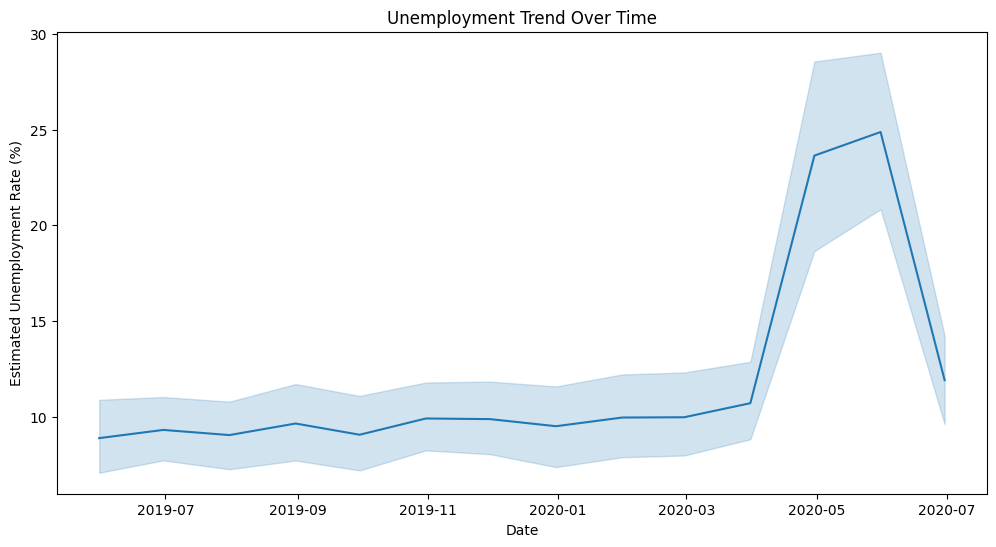

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment Trend Over Time")
plt.show()

## Unemployment Trend Analysis

The line plot above illustrates the overall trend of unemployment rates over time in India. It shows fluctuations and significant spikes, particularly during certain periods.

**Average Unemployment by Region**

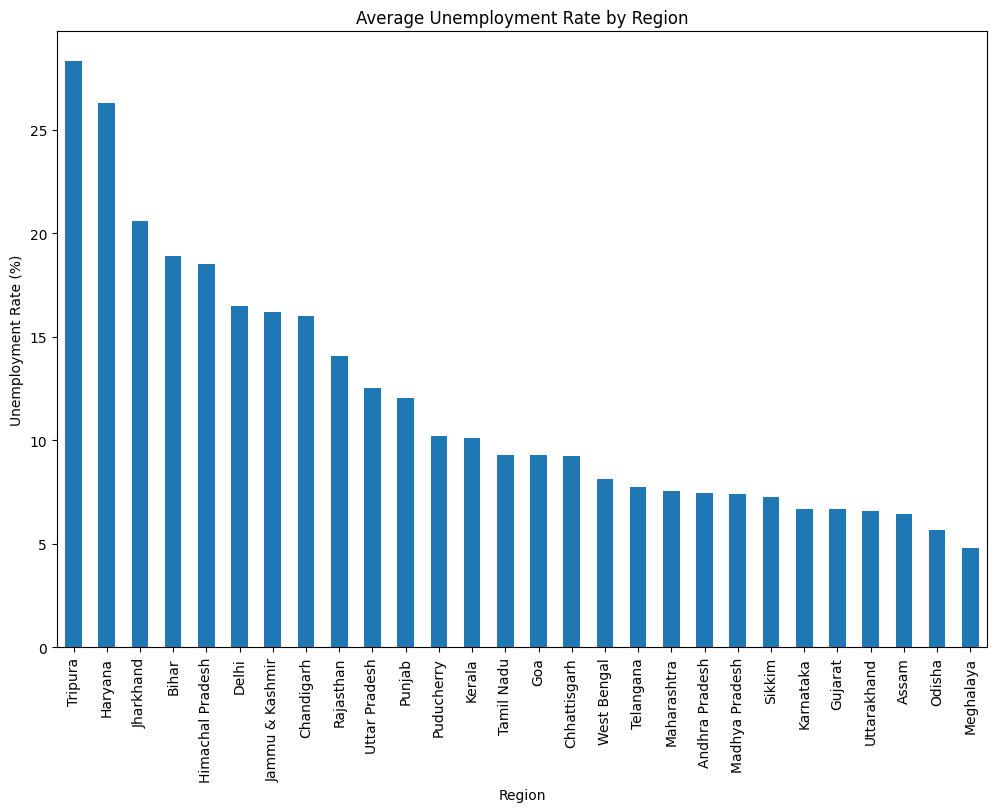

In [ ]:
region_avg = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

region_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")

plt.show()

## Regional Analysis

The bar chart above highlights the average unemployment rates across different regions. This helps in identifying states or regions that consistently experience higher or lower unemployment.

**COVID-19 Impact Analysis**

COVID period:

Before COVID → 2019
During COVID → 2020–2021

In [ ]:
covid = df[df['Year'] >= 2020]

before = df[df['Year'] < 2020]

print("Before Covid:",
      before['Estimated Unemployment Rate (%)'].mean())

print("During Covid:",
      covid['Estimated Unemployment Rate (%)'].mean())

Before Covid: 9.399046511627906
During Covid: 15.10158064516129


## COVID-19 Impact

To assess the impact of COVID-19, the data was split into 'Before Covid' (prior to 2020) and 'During Covid' (2020 onwards) periods. The mean unemployment rates for these periods indicate a substantial increase during the COVID-19 era. The box plot further visualizes the distribution of unemployment rates by year, clearly showing the elevated rates and wider spread during 2020 and 2021.

Visualisation

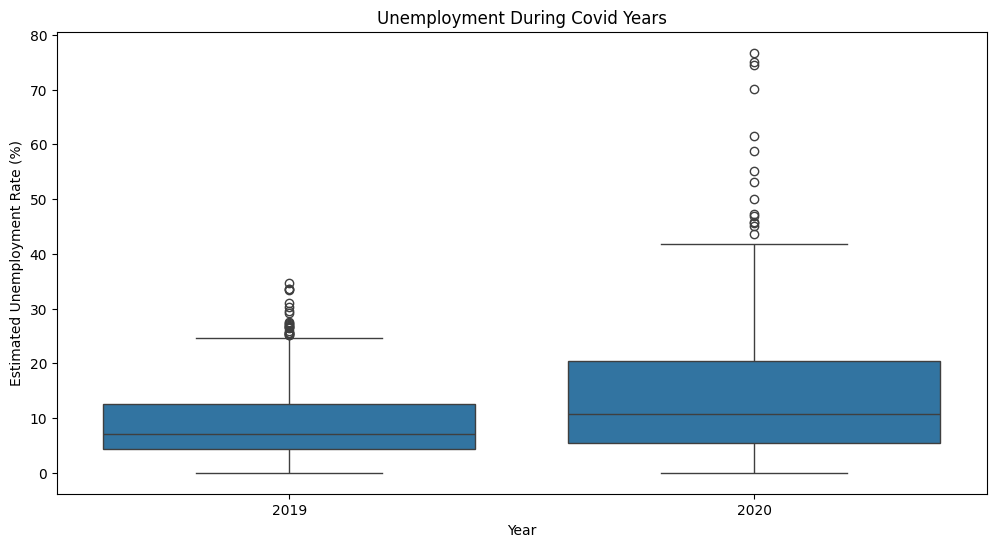

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Year',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment During Covid Years")

plt.show()

**Monthly Trend Analysis**

Identify seasonality.

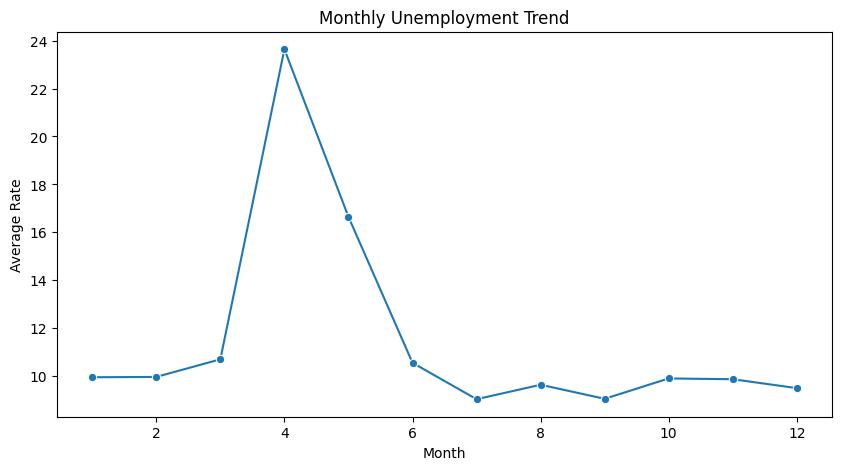

In [ ]:
monthly = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker='o'
)

plt.title("Monthly Unemployment Trend")

plt.xlabel("Month")
plt.ylabel("Average Rate")

plt.show()

## Seasonal Trend Analysis

The monthly line plot helps to identify seasonal patterns in unemployment. By averaging the unemployment rate for each month across all years, we can observe if certain months consistently have higher or lower unemployment, suggesting seasonality. The heatmap provides a regional and yearly breakdown, showing how unemployment rates vary across regions and years.

Heatmap Analysis

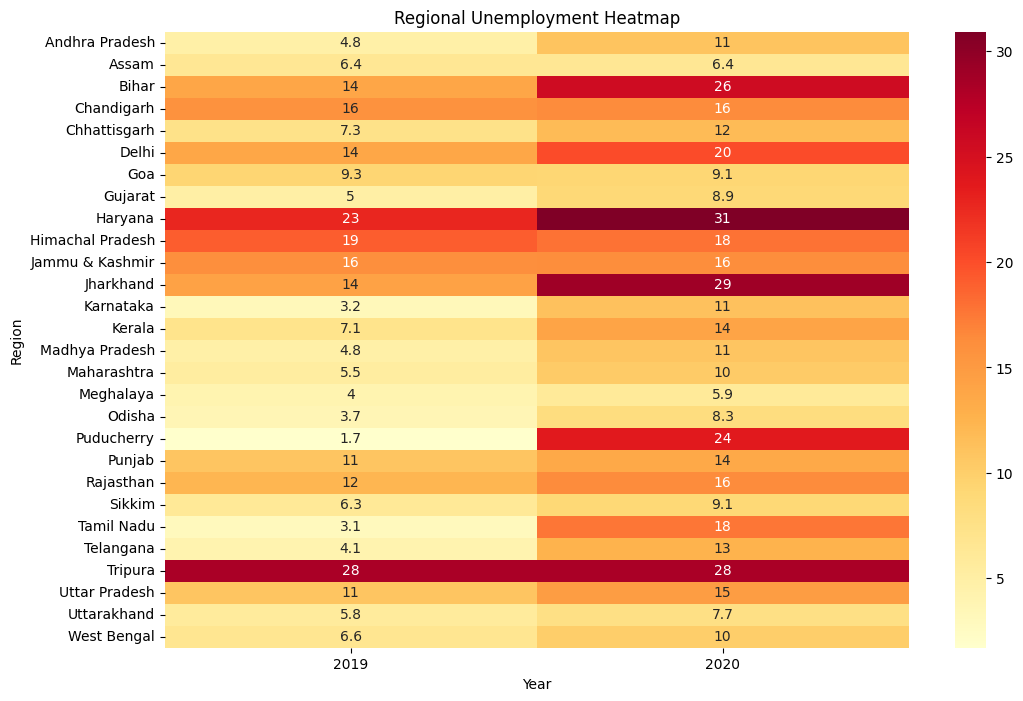

In [ ]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Year'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True
)

plt.title("Regional Unemployment Heatmap")

plt.show()

Top 10 Most Affected Regions

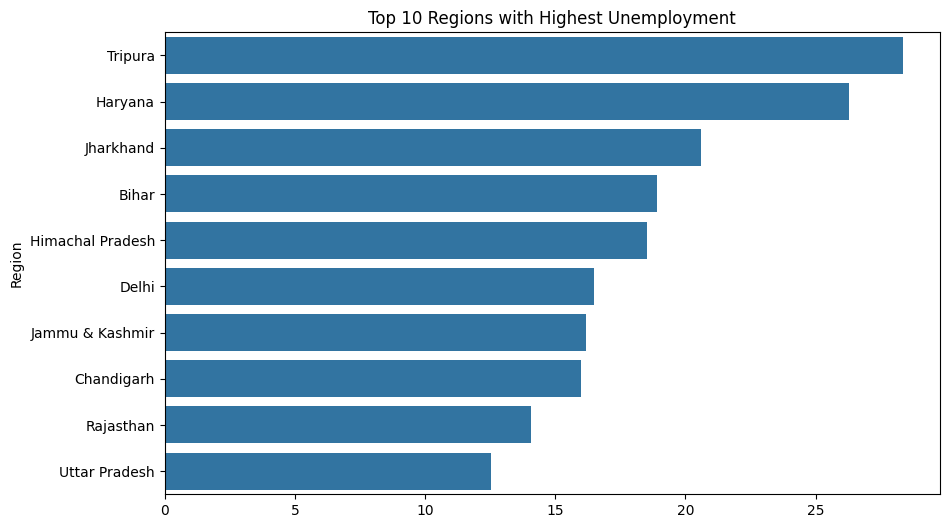

In [ ]:
top10 = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Regions with Highest Unemployment")

plt.show()

Interactive Dashboard using plotly

In [ ]:
import plotly.express as px

fig = px.line(
    df,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    color='Region',
    title='Interactive Unemployment Trend'
)

fig.show()

## Visualizations & Dashboard

Several visualizations were created to understand the data:
-   **Overall Unemployment Trend**: A line plot showing unemployment over time.
-   **Average Unemployment by Region**: A bar chart highlighting regional disparities.
-   **Unemployment During Covid Years**: Box plots illustrating the impact of COVID-19.
-   **Monthly Unemployment Trend**: A line plot to identify seasonality.
-   **Regional Unemployment Heatmap**: A heatmap to visualize unemployment rates across regions and years.
-   **Top 10 Regions with Highest Unemployment**: A bar chart showing the most affected regions.
-   **Interactive Unemployment Trend**: An interactive Plotly line plot for dynamic exploration of regional trends.

## Key Insights

-   Unemployment rates in India show significant fluctuations over time, with notable spikes during specific periods.
-   There are considerable regional disparities, with some states consistently experiencing higher average unemployment rates (e.g., Tripura, Haryana, Jharkhand).
-   The COVID-19 pandemic led to a substantial increase in the average unemployment rate, nearly doubling it from the pre-COVID period, and also resulted in a wider distribution of unemployment rates.
-   Seasonal patterns are observable, with certain months showing higher average unemployment.
-   The interactive dashboard allows for a detailed exploration of regional unemployment trends over time.

## Recommendations

1.  **Targeted Regional Interventions**: Focus on regions with persistently high unemployment rates, such as Tripura and Haryana, with specific job creation programs and skill development initiatives.
2.  **Economic Stabilization Measures**: Develop strategies to mitigate economic shocks, like pandemics, to prevent sharp increases in unemployment.
3.  **Seasonal Employment Support**: Implement policies or programs to support sectors and workers affected by seasonal unemployment.
4.  **Further Data Collection**: Collect more granular data (e.g., urban vs. rural breakdown across all regions, specific industry unemployment) to enable more precise policy interventions.
5.  **Policy Evaluation**: Continuously monitor the effectiveness of current employment policies and adapt them based on observed trends and regional needs.

## Conclusion

The analysis provides a comprehensive overview of unemployment dynamics in India, highlighting the critical impact of economic events and regional disparities. Understanding these trends is crucial for informed policy-making aimed at fostering sustainable employment and economic stability.